# PM10 1시간 뒤 등급 예측 모델 학습 (2023-2024)

## 0. 패키지 설치

In [27]:
%pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn tensorflow openpyxl xlrd xgboost
print('✅ 라이브러리 설치 완료')

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
✅ 라이브러리 설치 완료


## 1. 환경 설정

In [28]:
import os

dirs = [
    "data/raw",
    "data/merged",
    "data/featured",
    "data/model_input",
    "models/preprocess",
    "models/tensorflow",
    "models/tree",
    "outputs/plots",
    "outputs/predictions",
    "outputs/metrics"
]

for d in dirs:
    os.makedirs(d, exist_ok=True)

print('✅ 디렉토리 생성 완료')

✅ 디렉토리 생성 완료


## 2. 라이브러리

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import joblib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Mac 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

print('✅ 라이브러리 로드 완료')

✅ 라이브러리 로드 완료


## 3. 데이터 불러오기

In [30]:
dust_2023 = pd.read_csv('dust_2023.csv')
dust_2024 = pd.read_csv('dust_2024.csv')
weather_2023 = pd.read_csv('weather_2023.csv')
weather_2024 = pd.read_csv('weather_2024.csv')

print('dust_2023:', dust_2023.shape)
print('dust_2024:', dust_2024.shape)
print('weather_2023:', weather_2023.shape)
print('weather_2024:', weather_2024.shape)

dust_2023: (5700503, 12)
dust_2024: (5819357, 12)
weather_2023: (8736, 38)
weather_2024: (8783, 38)


## 4. 데이터 전처리 및 병합

In [31]:
def preprocess_merge(dust, weather):
    dust = dust.copy()
    weather = weather.copy()

    dust.columns = dust.columns.str.strip()
    weather.columns = weather.columns.str.strip()

    dust['측정일시'] = pd.to_datetime(
        dust['측정일시'].astype(str).str.strip(),
        format='%Y%m%d%H',
        errors='coerce'
    )
    weather['일시'] = pd.to_datetime(
        weather['일시'].astype(str).str.strip(),
        errors='coerce'
    )

    dust = dust.rename(columns={'측정일시': 'datetime'})
    weather = weather.rename(columns={'일시': 'datetime'})

    dust = dust.dropna(subset=['datetime'])
    weather = weather.dropna(subset=['datetime'])

    df = pd.merge(dust, weather, on='datetime', how='inner')
    df = df.sort_values(['datetime', '지역', '측정소코드']).reset_index(drop=True)

    return df


# QC 플래그 컬럼 제거 함수
def drop_qc_cols(df):
    qc_cols = [c for c in df.columns if 'QC' in c]
    print('QC 제거:', qc_cols)
    return df.drop(columns=qc_cols)


merged_2023 = preprocess_merge(dust_2023, weather_2023)
merged_2024 = preprocess_merge(dust_2024, weather_2024)

merged_2023 = drop_qc_cols(merged_2023)
merged_2024 = drop_qc_cols(merged_2024)

# 서울 필터링
train_df = merged_2023[merged_2023['지역'].str.startswith('서울')].copy().reset_index(drop=True)
test_df  = merged_2024[merged_2024['지역'].str.startswith('서울')].copy().reset_index(drop=True)


print('서울 필터링 후 train_df:', train_df.shape)
print('서울 필터링 후 test_df :', test_df.shape)

# 데이터 샘플 확인
display(train_df.head())

QC 제거: ['기온 QC플래그', '강수량 QC플래그', '풍속 QC플래그', '풍향 QC플래그', '습도 QC플래그', '현지기압 QC플래그', '해면기압 QC플래그', '일조 QC플래그', '일사 QC플래그', '지면온도 QC플래그']
QC 제거: ['기온 QC플래그', '강수량 QC플래그', '풍속 QC플래그', '풍향 QC플래그', '습도 QC플래그', '현지기압 QC플래그', '해면기압 QC플래그', '일조 QC플래그', '일사 QC플래그', '지면온도 QC플래그']
서울 필터링 후 train_df: (334880, 39)
서울 필터링 후 test_df : (336720, 39)


,지역,망,측정소코드,측정소명,datetime,SO2,CO,O3,NO2,PM10,...,운형(운형약어),최저운고(100m ),시정(10m),지면상태(지면상태코드),현상번호(국내식),지면온도(°C),5cm 지중온도(°C),10cm 지중온도(°C),20cm 지중온도(°C),30cm 지중온도(°C)
0,서울 강남구,도시대기,111261,강남구,2023-01-01 01:00:00,0.004,0.9,0.003,0.051,51.0,...,NaN,12.0,1104,NaN,NaN,-1.4,-0.3,-0.5,-0.5,0.6
1,서울 강남구,도로변대기,111263,도산대로,2023-01-01 01:00:00,0.004,1.4,0.002,0.048,64.0,...,NaN,12.0,1104,NaN,NaN,-1.4,-0.3,-0.5,-0.5,0.6
2,서울 강동구,도시대기,111274,강동구,2023-01-01 01:00:00,0.003,1.0,0.002,0.051,69.0,...,NaN,12.0,1104,NaN,NaN,-1.4,-0.3,-0.5,-0.5,0.6
3,서울 강동구,도로변대기,111275,천호대로,2023-01-01 01:00:00,0.004,1.4,0.001,0.058,60.0,...,NaN,12.0,1104,NaN,NaN,-1.4,-0.3,-0.5,-0.5,0.6
4,서울 강북구,도시대기,111291,강북구,2023-01-01 01:00:00,0.003,1.5,0.002,NaN,73.0,...,NaN,12.0,1104,NaN,NaN,-1.4,-0.3,-0.5,-0.5,0.6


In [32]:
train_df.to_csv('data/merged/train_2023_merged.csv', index=False, encoding='utf-8-sig')
test_df.to_csv('data/merged/test_2024_merged.csv',   index=False, encoding='utf-8-sig')
print('✅ merged 저장 완료')

✅ merged 저장 완료


## 5. 피처 엔지니어링

In [33]:
# PM10 4단계 등급 레이블
def pm10_grade(pm10):
    if pm10 <= 30:  return 0  # 좋음
    elif pm10 <= 80:  return 1  # 보통
    elif pm10 <= 150: return 2  # 나쁨
    else:             return 3  # 매우나쁨

for df in [train_df, test_df]:
    df.sort_values(['측정소코드', 'datetime'], inplace=True)
    df.reset_index(drop=True, inplace=True)
    df['PM10_future_1h'] = df.groupby('측정소코드')['PM10'].shift(-1)
    df['grade_future_1h'] = df['PM10_future_1h'].apply(pm10_grade)

train_df.dropna(subset=['PM10_future_1h'], inplace=True)
test_df.dropna(subset=['PM10_future_1h'],  inplace=True)
train_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

print('클래스 분포 (train):')
print(train_df['grade_future_1h'].value_counts().sort_index())
print('\n클래스 분포 (test):')
print(test_df['grade_future_1h'].value_counts().sort_index())

클래스 분포 (train):
grade_future_1h
0    157211
1    143506
2     22848
3      3403
Name: count, dtype: int64

클래스 분포 (test):
grade_future_1h
0    185845
1    131997
2      9725
3      1513
Name: count, dtype: int64


In [34]:
# 시간 파생변수
def add_time_features(df):
    df = df.copy()
    df['month']     = df['datetime'].dt.month
    df['day']       = df['datetime'].dt.day
    df['hour']      = df['datetime'].dt.hour
    df['dayofweek'] = df['datetime'].dt.dayofweek

    def season_map(m):
        if m in [3,4,5]:   return 'Spring'
        elif m in [6,7,8]: return 'Summer'
        elif m in [9,10,11]: return 'Autumn'
        else:              return 'Winter'

    df['season'] = df['month'].apply(season_map)
    return df

train_df = add_time_features(train_df)
test_df  = add_time_features(test_df)

In [35]:
# 강수 파생변수
def add_precip_features(df):
    df = df.copy()
    if '강수량(mm)' in df.columns:
        df['precip_class']    = df['강수량(mm)'].apply(
            lambda x: np.nan if pd.isna(x) else (0 if x==0 else (1 if x<3 else (2 if x<15 else 3)))
        )
        df['precip_weighted'] = df['강수량(mm)'].apply(
            lambda x: x*2.0 if pd.notna(x) and x>=15 else x
        )
        df['rain_binary']     = df['강수량(mm)'].apply(
            lambda x: 1 if pd.notna(x) and x>0 else 0
        )
    return df

train_df = add_precip_features(train_df)
test_df  = add_precip_features(test_df)

In [36]:
# lag 피처
def add_lag_features(df):
    df = df.copy()
    df = df.sort_values(['측정소코드', 'datetime']).reset_index(drop=True)
    df['pm10_lag1']   = df.groupby('측정소코드')['PM10'].shift(1)
    df['pm10_lag2']   = df.groupby('측정소코드')['PM10'].shift(2)
    df['pm10_lag3']   = df.groupby('측정소코드')['PM10'].shift(3)
    df['pm25_lag1']   = df.groupby('측정소코드')['PM25'].shift(1)
    df['pm25_lag2']   = df.groupby('측정소코드')['PM25'].shift(2)
    df['precip_lag1'] = df.groupby('측정소코드')['강수량(mm)'].shift(1)
    df['precip_lag2'] = df.groupby('측정소코드')['강수량(mm)'].shift(2)
    return df

train_df = add_lag_features(train_df)
test_df  = add_lag_features(test_df)

In [37]:
train_df.to_csv('data/featured/train_2023_featured.csv', index=False, encoding='utf-8-sig')
test_df.to_csv('data/featured/test_2024_featured.csv',   index=False, encoding='utf-8-sig')
print('✅ featured 저장 완료')

✅ featured 저장 완료


## 6. 모델 입력 데이터 구성

In [38]:
exclude_cols = [
    'grade_future_1h', 'PM10_future_1h', 'datetime', 'PM10',
    '주소', '측정소명', '지점명', '강수량(mm)', '지역', '망'
]

candidate_cols = [c for c in train_df.columns if c not in exclude_cols]
print('입력 후보 컬럼 수:', len(candidate_cols))

입력 후보 컬럼 수: 46


In [39]:
# 수치형 / 범주형 분류
numeric_cols     = []
categorical_cols = []

for col in candidate_cols:
    series = train_df[col]
    if pd.api.types.is_object_dtype(series) or pd.api.types.is_categorical_dtype(series):
        categorical_cols.append(col)
    elif pd.api.types.is_numeric_dtype(series):
        nunique      = series.nunique(dropna=True)
        unique_ratio = nunique / max(len(series.dropna()), 1)
        if nunique <= 20 and unique_ratio < 0.01:
            categorical_cols.append(col)
        else:
            numeric_cols.append(col)

force_categorical = ['month', 'season', '측정소코드', 'precip_class', 'rain_binary']
for col in force_categorical:
    if col in numeric_cols:
        numeric_cols.remove(col)
    if col not in categorical_cols:
        categorical_cols.append(col)

categorical_cols = list(dict.fromkeys(categorical_cols))

print('numeric_cols:', len(numeric_cols))
print('categorical_cols:', len(categorical_cols))

numeric_cols: 33
categorical_cols: 13


In [40]:
needed_cols = numeric_cols + categorical_cols + ['grade_future_1h', 'datetime']

train_model_df = train_df[needed_cols].copy()
test_model_df  = test_df[needed_cols].copy()

print('train_model_df:', train_model_df.shape)
print('test_model_df :', test_model_df.shape)
display(train_model_df.head())

train_model_df: (326968, 48)
test_model_df : (329080, 48)


,SO2,CO,O3,NO2,PM25,기온(°C),풍속(m/s),습도(%),증기압(hPa),이슬점온도(°C),...,운형(운형약어),지면상태(지면상태코드),month,dayofweek,season,precip_class,rain_binary,측정소코드,grade_future_1h,datetime
0,0.004,0.8,0.004,0.055,52.0,1.5,1.9,71,4.9,-3.1,...,NaN,NaN,1,6,Winter,NaN,0,111121,1,2023-01-01 01:00:00
1,0.004,0.8,0.004,0.051,60.0,1.5,1.9,72,4.9,-3.0,...,NaN,NaN,1,6,Winter,NaN,0,111121,1,2023-01-01 02:00:00
2,0.004,0.8,0.005,0.048,63.0,1.6,1.6,74,5.1,-2.5,...,Sc,NaN,1,6,Winter,NaN,0,111121,1,2023-01-01 03:00:00
3,0.004,0.7,0.014,0.032,71.0,1.5,1.4,74,5.0,-2.6,...,Sc,NaN,1,6,Winter,NaN,0,111121,1,2023-01-01 04:00:00
4,0.004,0.7,0.021,0.021,73.0,0.8,2.4,62,4.0,-5.6,...,Sc,NaN,1,6,Winter,NaN,0,111121,1,2023-01-01 05:00:00


In [41]:
# 결측 처리
numeric_cols     = [c for c in numeric_cols     if c in train_model_df.columns]
categorical_cols = [c for c in categorical_cols if c in train_model_df.columns]

all_nan_numeric     = [c for c in numeric_cols     if train_model_df[c].isnull().all()]
all_nan_categorical = [c for c in categorical_cols if train_model_df[c].isnull().all()]

numeric_cols     = [c for c in numeric_cols     if c not in all_nan_numeric]
categorical_cols = [c for c in categorical_cols if c not in all_nan_categorical]

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

if numeric_cols:
    train_model_df[numeric_cols] = num_imputer.fit_transform(train_model_df[numeric_cols])
    test_model_df[numeric_cols]  = num_imputer.transform(test_model_df[numeric_cols])

if categorical_cols:
    train_model_df[categorical_cols] = cat_imputer.fit_transform(train_model_df[categorical_cols])
    test_model_df[categorical_cols]  = cat_imputer.transform(test_model_df[categorical_cols])

print('결측 처리 후 train missing:', train_model_df.isnull().sum().sum())
print('결측 처리 후 test  missing:', test_model_df.isnull().sum().sum())

결측 처리 후 train missing: 326968
결측 처리 후 test  missing: 329080


In [42]:
# 원-핫 인코딩
train_encoded = pd.get_dummies(train_model_df, columns=categorical_cols, drop_first=False)
test_encoded  = pd.get_dummies(test_model_df,  columns=categorical_cols, drop_first=False)

train_encoded, test_encoded = train_encoded.align(test_encoded, join='left', axis=1, fill_value=0)

print('train_encoded:', train_encoded.shape)
print('test_encoded :', test_encoded.shape)

train_encoded: (326968, 188)
test_encoded : (329080, 188)


In [43]:
train_encoded.to_csv('data/model_input/train_2023_model_input.csv', index=False, encoding='utf-8-sig')
test_encoded.to_csv('data/model_input/test_2024_model_input.csv',   index=False, encoding='utf-8-sig')
print('✅ 모델 입력 데이터 저장 완료')

✅ 모델 입력 데이터 저장 완료


## 7. 탐색적 분석 (EDA)

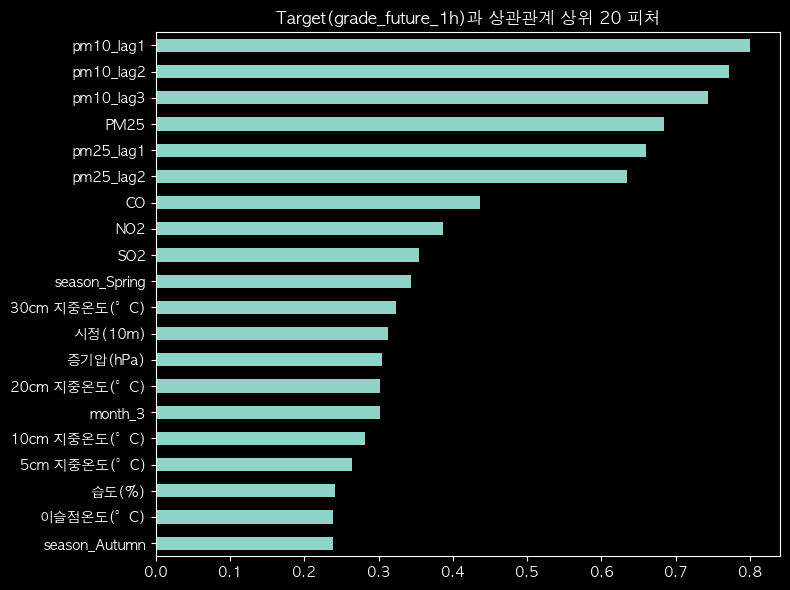

In [44]:
# target과의 상관관계 상위 20개
all_features = [c for c in train_encoded.columns if c not in ['grade_future_1h', 'datetime']]

# corrwith()로 target과의 상관만 계산 (전체 corr()보다 훨씬 빠름)
corr_with_target = train_encoded[all_features].corrwith(train_encoded['grade_future_1h'])
top20_corr = corr_with_target.abs().sort_values(ascending=False).head(20)

plt.figure(figsize=(8, 6))
top20_corr.sort_values().plot(kind='barh')
plt.title('Target(grade_future_1h)과 상관관계 상위 20 피처')
plt.tight_layout()
plt.savefig('outputs/plots/plot_target_corr_top20.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. 1차 모델 학습 (피처 선택용)

In [45]:
X_train = train_encoded[all_features]
y_train = train_encoded['grade_future_1h'].astype(int)
X_test  = test_encoded[all_features]
y_test  = test_encoded['grade_future_1h'].astype(int)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)

X_train: (326968, 186)
X_test : (329080, 186)


In [46]:
# 1차 XGBoost (feature importance 추출용)
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)
xgb_model.fit(X_train_scaled, y_train)
print('✅ 1차 XGBoost 학습 완료')

✅ 1차 XGBoost 학습 완료


,feature,importance
26,pm10_lag1,0.237883
27,pm10_lag2,0.050920
28,pm10_lag3,0.037201
4,PM25,0.022560
137,season_Spring,0.022044
116,운형(운형약어)_StNs,0.020621
141,precip_class_1.0,0.011733
25,precip_weighted,0.011629
144,rain_binary_0,0.010724
136,season_Autumn,0.010357


<Figure size 1200x1000 with 0 Axes>

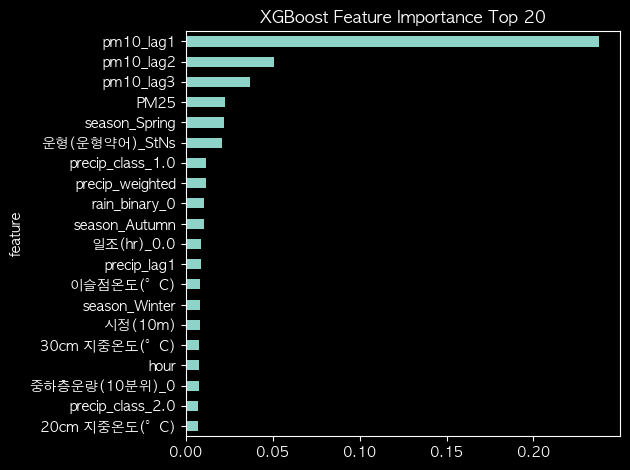

In [47]:
# Feature Importance Top 20 시각화
importance_df = pd.DataFrame({
    'feature':    X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

display(importance_df.head(20))

plt.figure(figsize=(12, 10))
importance_df.head(20).sort_values('importance').plot(
    x='feature', y='importance', kind='barh', legend=False
)
plt.title('XGBoost Feature Importance Top 20')
plt.tight_layout()
plt.savefig('outputs/plots/plot_xgb_importance_top20.png', dpi=300, bbox_inches='tight')
plt.show()

In [48]:
# 중요도 기준 피처 선택
threshold = 0.001

important_features = importance_df[
    importance_df['importance'] > threshold
]['feature'].tolist()

print('선택된 feature 수:', len(important_features))
print(important_features[:20])

선택된 feature 수: 154
['pm10_lag1', 'pm10_lag2', 'pm10_lag3', 'PM25', 'season_Spring', '운형(운형약어)_StNs', 'precip_class_1.0', 'precip_weighted', 'rain_binary_0', 'season_Autumn', '일조(hr)_0.0', 'precip_lag1', '이슬점온도(°C)', 'season_Winter', '시정(10m)', '30cm 지중온도(°C)', 'hour', '중하층운량(10분위)_0', 'precip_class_2.0', '20cm 지중온도(°C)']


## 9. 최종 모델 학습

In [49]:
# 선택된 피처로 재구성
X_train_final = X_train[important_features]
X_test_final  = X_test[important_features]

print('X_train_final:', X_train_final.shape)
print('X_test_final :', X_test_final.shape)

X_train_final: (326968, 154)
X_test_final : (329080, 154)


In [50]:
# 스케일링
scaler_final = StandardScaler()
X_train_final_scaled = scaler_final.fit_transform(X_train_final)
X_test_final_scaled  = scaler_final.transform(X_test_final)

In [51]:
# 클래스 가중치
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict   = {cls: w for cls, w in zip(classes, weights)}
sample_weight_final = pd.Series(y_train).map(class_weight_dict).values

print('class_weight_dict:', class_weight_dict)

class_weight_dict: {np.int64(0): np.float64(0.5199508940214107), np.int64(1): np.float64(0.5696068457067998), np.int64(2): np.float64(3.5776435574229692), np.int64(3): np.float64(24.020570085218925)}


In [52]:
# TensorFlow
model_final = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_final_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(4, activation='softmax')
])

model_final.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_final.fit(
    X_train_final_scaled, y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.2,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/20
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6505 - loss: 0.7579 - val_accuracy: 0.8224 - val_loss: 0.4278
Epoch 2/20
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8291 - loss: 0.3697 - val_accuracy: 0.8302 - val_loss: 0.4126
Epoch 3/20
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8476 - loss: 0.3133 - val_accuracy: 0.8448 - val_loss: 0.3890
Epoch 4/20
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8562 - loss: 0.3000 - val_accuracy: 0.8366 - val_loss: 0.4132
Epoch 5/20
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8608 - loss: 0.2836 - val_accuracy: 0.8253 - val_loss: 0.4426
Epoch 6/20
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8639 - loss: 0.2718 - val_accuracy: 0.8112 - val_loss: 0.4853
Epoch 7/20
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8669 - loss: 0.2697 - val_accuracy: 0.7891 - val_loss: 0.6035
Epoch 8/20
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8694 - loss: 0.2600 - 

In [53]:
# XGBoost (최종)
xgb_final = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)
xgb_final.fit(X_train_final_scaled, y_train, sample_weight=sample_weight_final)

# RandomForest (최종)
rf_final = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_final.fit(X_train_final_scaled, y_train)

print('✅ 최종 모델 학습 완료')

✅ 최종 모델 학습 완료


## 10. 매우나쁨 Threshold 실험

,threshold,accuracy,macro_f1,vb_precision,vb_f1
0,0.10,0.8749,0.7388,0.4232,0.5728
1,0.15,0.8756,0.7515,0.4730,0.6128
2,0.20,0.8759,0.7581,0.5023,0.6320
3,0.25,0.8763,0.7639,0.5294,0.6491
4,0.30,0.8766,0.7707,0.5608,0.6692


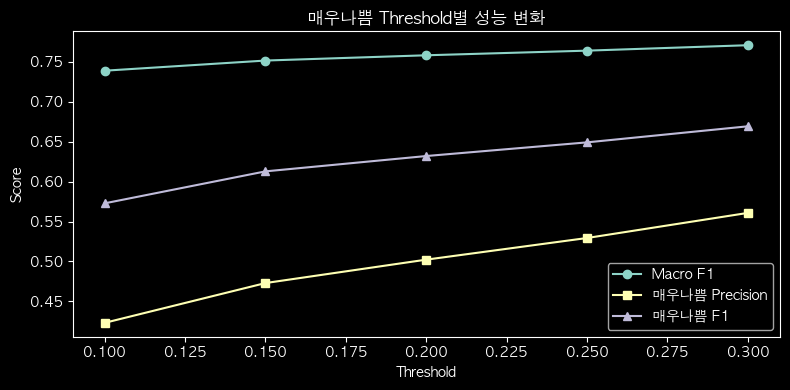


→ Macro F1과 매우나쁨 F1을 동시에 고려하여 최적 threshold를 선택하세요.


In [54]:
# XGBoost 확률 예측
xgb_probs = xgb_final.predict_proba(X_test_final_scaled)

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30]
results = []

for t in thresholds:
    preds = np.where(xgb_probs[:, 3] >= t, 3, xgb_probs.argmax(axis=1))
    acc     = accuracy_score(y_test, preds)
    macro_f1 = f1_score(y_test, preds, average='macro')
    recall_vb = f1_score(y_test, preds, average=None)[3]  # 매우나쁨 recall
    prec_vb   = classification_report(y_test, preds, output_dict=True)['3']['precision']
    results.append({
        'threshold':         t,
        'accuracy':          round(acc, 4),
        'macro_f1':          round(macro_f1, 4),
        'vb_precision':      round(prec_vb, 4),
        'vb_f1':             round(recall_vb, 4),
    })

threshold_df = pd.DataFrame(results)
display(threshold_df)

# 시각화
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(threshold_df['threshold'], threshold_df['macro_f1'],  marker='o', label='Macro F1')
ax.plot(threshold_df['threshold'], threshold_df['vb_precision'], marker='s', label='매우나쁨 Precision')
ax.plot(threshold_df['threshold'], threshold_df['vb_f1'],     marker='^', label='매우나쁨 F1')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('매우나쁨 Threshold별 성능 변화')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/plots/plot_threshold_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n→ Macro F1과 매우나쁨 F1을 동시에 고려하여 최적 threshold를 선택하세요.')

## 11. 최종 평가

In [55]:
# threshold 위 실험 결과 보고 선택
BEST_THRESHOLD = 0.20

tf_probs_final  = model_final.predict(X_test_final_scaled)
tf_pred_final   = np.where(tf_probs_final[:, 3] > 0.30, 3, tf_probs_final.argmax(axis=1))

xgb_pred_final  = np.where(xgb_probs[:, 3] >= BEST_THRESHOLD, 3, xgb_probs.argmax(axis=1))

rf_pred_final   = rf_final.predict(X_test_final_scaled)

for name, preds in [('TensorFlow', tf_pred_final),
                     ('XGBoost',    xgb_pred_final),
                     ('RandomForest', rf_pred_final)]:
    print(f'=== FINAL {name} ===')
    print('Accuracy :', accuracy_score(y_test, preds))
    print('Macro F1 :', f1_score(y_test, preds, average='macro'))
    print(classification_report(y_test, preds, digits=4))
    print(confusion_matrix(y_test, preds))
    print()

10284/10284 ━━━━━━━━━━━━━━━━━━━━ 4s 380us/step
=== FINAL TensorFlow ===
Accuracy : 0.8442263279445728
Macro F1 : 0.6519005380605237
              precision    recall  f1-score   support

           0     0.8698    0.9306    0.8992    185845
           1     0.8714    0.7385    0.7995    131997
           2     0.4638    0.6313    0.5347      9725
           3     0.2423    0.8215    0.3742      1513

    accuracy                         0.8442    329080
   macro avg     0.6118    0.7805    0.6519    329080
weighted avg     0.8556    0.8442    0.8460    329080

[[172955  12865     10     15]
 [ 25824  97481   6893   1799]
 [    50   1463   6139   2073]
 [    22     53    195   1243]]

=== FINAL XGBoost ===
Accuracy : 0.8759420201774645
Macro F1 : 0.758088873370941
              precision    recall  f1-score   support

           0     0.9060    0.9184    0.9122    185845
           1     0.8677    0.8278    0.8472    131997
           2     0.5755    0.7231    0.6409      9725
         

## 12. 결과 저장

In [56]:
final_result_df = pd.DataFrame({
    'datetime':             test_encoded['datetime'].values,
    'actual_grade_future_1h': y_test.values,
    'tf_pred_future_1h':    tf_pred_final,
    'xgb_pred_future_1h':   xgb_pred_final,
    'rf_pred_future_1h':    rf_pred_final
})

final_result_df.to_csv(
    'outputs/predictions/pred_2024_final.csv',
    index=False, encoding='utf-8-sig'
)
display(final_result_df.head())
print('✅ 예측 결과 저장 완료')

,datetime,actual_grade_future_1h,tf_pred_future_1h,xgb_pred_future_1h,rf_pred_future_1h
0,2024-01-01 01:00:00,0,1,1,1
1,2024-01-01 03:00:00,0,0,0,1
2,2024-01-01 05:00:00,0,0,0,1
3,2024-01-01 07:00:00,0,1,1,1
4,2024-01-01 08:00:00,0,1,0,1


✅ 예측 결과 저장 완료


In [57]:
# 모델 저장
model_final.save('models/tensorflow/dust_tf_model_final_v2.keras')
joblib.dump(xgb_final, 'models/tree/dust_xgb_model_final_v2.pkl')
joblib.dump(rf_final,  'models/tree/dust_rf_model_final_v2.pkl')

# 전처리 저장
joblib.dump(scaler_final,       'models/preprocess/dust_scaler_final_v2.pkl')
joblib.dump(important_features, 'models/preprocess/dust_selected_features_final.pkl')
joblib.dump(train_encoded.columns.tolist(), 'models/preprocess/dust_encoded_columns_final.pkl')

print('✅ 모델 및 전처리 파일 저장 완료')

✅ 모델 및 전처리 파일 저장 완료


## 13 모델 성능 시각화

## 13-1 Confusion Matrix

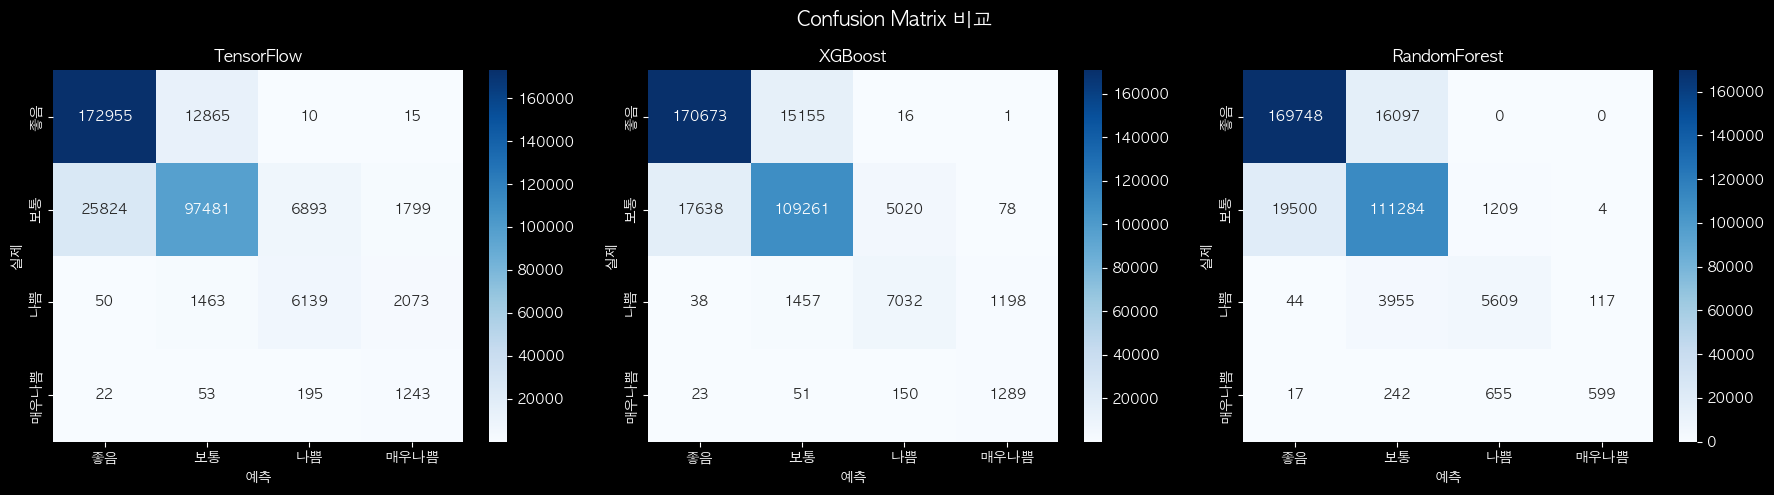

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, preds) in zip(axes, [
    ('TensorFlow', tf_pred_final),
    ('XGBoost',    xgb_pred_final),
    ('RandomForest', rf_pred_final)
]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
        xticklabels=['좋음','보통','나쁨','매우나쁨'],
        yticklabels=['좋음','보통','나쁨','매우나쁨'],
        cmap='Blues')
    ax.set_title(name)
    ax.set_xlabel('예측')
    ax.set_ylabel('실제')

plt.suptitle('Confusion Matrix 비교', fontsize=14)
plt.tight_layout()
plt.savefig('outputs/plots/plot_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

## 13-2 모델별 성능 비교

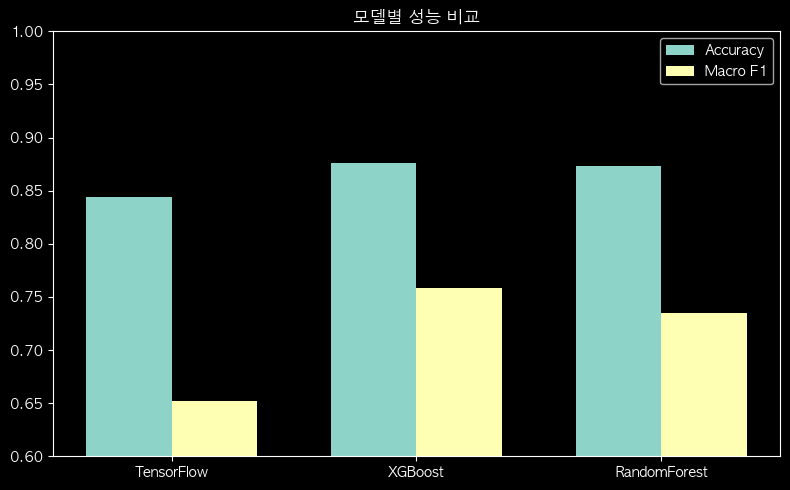

In [59]:
models = ['TensorFlow', 'XGBoost', 'RandomForest']
accuracies = [
    accuracy_score(y_test, tf_pred_final),
    accuracy_score(y_test, xgb_pred_final),
    accuracy_score(y_test, rf_pred_final)
]
macro_f1s = [
    f1_score(y_test, tf_pred_final, average='macro'),
    f1_score(y_test, xgb_pred_final, average='macro'),
    f1_score(y_test, rf_pred_final, average='macro')
]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, accuracies, width, label='Accuracy')
ax.bar(x + width/2, macro_f1s,  width, label='Macro F1')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.6, 1.0)
ax.set_title('모델별 성능 비교')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/plots/plot_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 13-3 클래스 분포

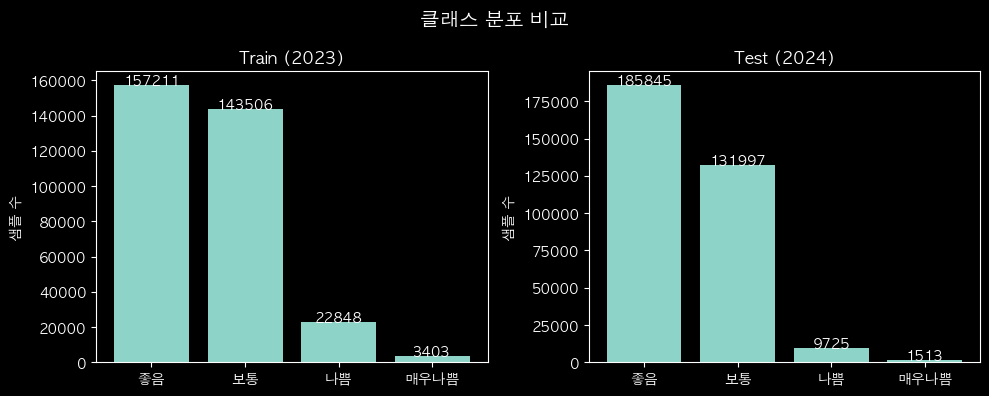

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
grade_labels = ['좋음', '보통', '나쁨', '매우나쁨']

for ax, (title, y) in zip(axes, [('Train (2023)', y_train), ('Test (2024)', y_test)]):
    counts = pd.Series(y).value_counts().sort_index()
    ax.bar(grade_labels, counts.values)
    ax.set_title(title)
    ax.set_ylabel('샘플 수')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 100, str(v), ha='center')

plt.suptitle('클래스 분포 비교', fontsize=14)
plt.tight_layout()
plt.savefig('outputs/plots/plot_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()